# Yield Prediction Data Cleaning and Visualization 

***Goal:*** given a farmer's Crop, Season, Farm Area, and their region's Annual Rainfall,
predict three outputs together **recommended Fertilizer rate, recommended Pesticide
rate, and expected Yield** so a farmer can compare their planned inputs against what
similar farms have achieved.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

In [4]:
df_raw = pd.read_csv('crop_yield.csv')
print('Shape:', df_raw.shape)
print()
print(df_raw.dtypes)
print()
print(df_raw.head())

Shape: (19689, 10)

Crop                   str
Crop_Year            int64
Season                 str
State                  str
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.3

In [5]:
print('Missing values per column:')
print(df_raw.isnull().sum())
print()
print('Duplicate rows:', df_raw.duplicated().sum())
print()
print('Unique Crops:', df_raw['Crop'].nunique())
print('Unique States:', df_raw['State'].nunique())
print('Raw Season values:', df_raw['Season'].unique().tolist())

Missing values per column:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

Duplicate rows: 0

Unique Crops: 55
Unique States: 30
Raw Season values: ['Whole Year ', 'Kharif     ', 'Rabi       ', 'Autumn     ', 'Summer     ', 'Winter     ']


Visualisation before cleaning

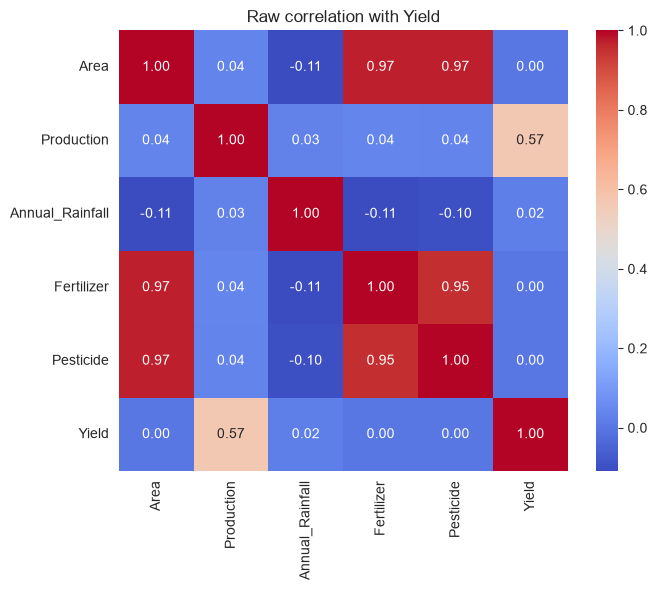

In [6]:
num_cols_raw = ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_raw[num_cols_raw].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Raw correlation with Yield')
plt.tight_layout()
plt.show()

Data Cleaning

In [7]:
# Season mapping
df = df_raw.copy()
df['Crop'] = df['Crop'].str.strip()
df['Season'] = df['Season'].str.strip()

df = df.drop(columns=['State'])

season_map = {
    'Kharif': 'Rainy Season',
    'Autumn': 'Rainy Season',
    'Rabi': 'Dry Season',
    'Winter': 'Dry Season',
    'Summer': 'Dry Season',
    'Whole Year': 'Year-Round',
}
df['Season_Mapped'] = df['Season'].map(season_map)
assert df['Season_Mapped'].isnull().sum() == 0, 'Unmapped season value found'

print('Mapped season counts:')
print(df['Season_Mapped'].value_counts())

Mapped season counts:
Season_Mapped
Rainy Season    8646
Dry Season      7326
Year-Round      3717
Name: count, dtype: int64


In [8]:
# Production kept for reference/EDA but excluded from model features (leakage) — flagged, not dropped from df
df['Fertilizer_per_area'] = df['Fertilizer'] / df['Area']
df['Pesticide_per_area'] = df['Pesticide'] / df['Area']

print(df[['Fertilizer_per_area', 'Pesticide_per_area']].describe())

       Fertilizer_per_area  Pesticide_per_area
count         19689.000000        19689.000000
mean            137.160208            0.274374
std              26.200647            0.073284
min              94.670000            0.090000
25%             108.340000            0.220000
50%             144.490000            0.270000
75%             157.910000            0.330000
max             193.610000            0.380000


In [9]:
# Outlier removal
before_rows = len(df)

def cap_within_crop(frame, col, lo=0.01, hi=0.99):
    bounds = frame.groupby('Crop')[col].transform(lambda s: s.quantile(lo))
    upper = frame.groupby('Crop')[col].transform(lambda s: s.quantile(hi))
    return frame[(frame[col] >= bounds) & (frame[col] <= upper)]

df_clean = df.copy()
for col in ['Yield', 'Fertilizer_per_area', 'Pesticide_per_area']:
    df_clean = cap_within_crop(df_clean, col)

after_rows = len(df_clean)
print(f'Rows before outlier removal: {before_rows}')
print(f'Rows after outlier removal:  {after_rows}')
print(f'Removed: {before_rows - after_rows} rows ({(before_rows-after_rows)/before_rows*100:.1f}%)')

df_clean.to_csv('crop_yield_cleaned.csv', index=False)


Rows before outlier removal: 19689
Rows after outlier removal:  19093
Removed: 596 rows (3.0%)


Visualization After Cleaning

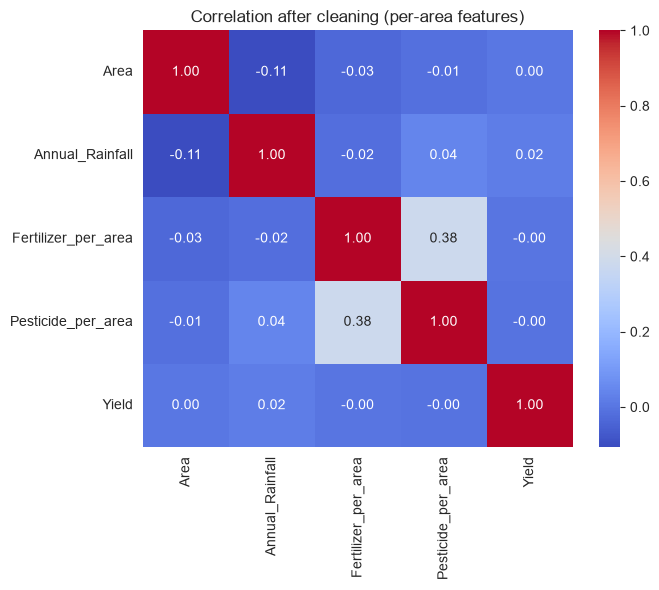

In [10]:
num_cols_clean = ['Area', 'Annual_Rainfall', 'Fertilizer_per_area', 'Pesticide_per_area', 'Yield']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_clean[num_cols_clean].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation after cleaning (per-area features)')
plt.tight_layout()
plt.show()

Train / Validation / Test Split (70% / 15% / 15%)

In [11]:
FEATURES = ['Crop', 'Season_Mapped', 'Area', 'Annual_Rainfall']
TARGETS = ['Yield', 'Fertilizer_per_area', 'Pesticide_per_area']

X = df_clean[FEATURES]
y = df_clean[TARGETS]
strat = df_clean['Crop']

X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, strat, test_size=0.30, random_state=RANDOM_STATE, stratify=strat)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=strat_temp)

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)

Train: (13365, 4)  Val: (2864, 4)  Test: (2864, 4)


Model Training — Multi-Output (Yield, Fertilizer, Pesticide)

We're going to predict all three numbers — Yield, Fertilizer rate, Pesticide rate — from the same four inputs. We'll try a few different model types, see which works best, tune it to squeeze out more accuracy, and finally check whether training one shared model per algorithm or three separate ones per target works better.

In [12]:
CAT_COLS = ['Crop', 'Season_Mapped']
NUM_COLS = ['Area', 'Annual_Rainfall']

def make_pipeline(estimator):
    return Pipeline([
        ('prep', ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
        ], remainder='passthrough')),
        ('model', estimator)
    ])

candidates = {
    'LinearRegression': make_pipeline(LinearRegression()),
    'RandomForest': make_pipeline(RandomForestRegressor(n_estimators=300, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1)),
    'GradientBoosting (per-target)': make_pipeline(MultiOutputRegressor(GradientBoostingRegressor(random_state=RANDOM_STATE))),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in candidates.items():
    fold_maes = {t: [] for t in TARGETS}
    for train_idx, val_idx in kf.split(X_train):
        pipe.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        preds = pipe.predict(X_train.iloc[val_idx])
        for i, t in enumerate(TARGETS):
            fold_maes[t].append(mean_absolute_error(y_train.iloc[val_idx][t], preds[:, i]))
    cv_results[name] = {t: np.mean(v) for t, v in fold_maes.items()}

cv_df = pd.DataFrame(cv_results).T
cv_df.columns = [f'{t}_MAE' for t in TARGETS]
print('5-fold CV mean absolute error by model and target (lower is better):')
print(cv_df.round(3))


5-fold CV mean absolute error by model and target (lower is better):
                               Yield_MAE  Fertilizer_per_area_MAE  \
LinearRegression                 148.431                   23.226   
RandomForest                      13.455                   17.516   
GradientBoosting (per-target)     16.983                   19.934   

                               Pesticide_per_area_MAE  
LinearRegression                                0.060  
RandomForest                                    0.052  
GradientBoosting (per-target)                   0.051  


In [13]:
# Which family looked best untuned, just to orient the tuning effort below
target_stds = y_train.std()
scaled = cv_df.copy()
for t in TARGETS:
    scaled[f'{t}_MAE'] = scaled[f'{t}_MAE'] / target_stds[t]
scaled['avg_scaled_MAE'] = scaled.mean(axis=1)
print(scaled.round(3))
print(f"\nUntuned leader: {scaled['avg_scaled_MAE'].idxmin()} — tuning all three below anyway,")
print('since default hyperparameters rarely reflect a model\'s true ceiling.')

                               Yield_MAE  Fertilizer_per_area_MAE  \
LinearRegression                   0.174                    0.896   
RandomForest                       0.016                    0.675   
GradientBoosting (per-target)      0.020                    0.769   

                               Pesticide_per_area_MAE  avg_scaled_MAE  
LinearRegression                                0.823           0.631  
RandomForest                                    0.706           0.466  
GradientBoosting (per-target)                   0.691           0.493  

Untuned leader: RandomForest — tuning all three below anyway,
since default hyperparameters rarely reflect a model's true ceiling.


# Hyperparameter tuning

In [14]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.linear_model import Ridge

def scaled_neg_mae(y_true, y_pred):
    # lower MAE is better - negate so sklearn's "greater_is_better" search logic still applies
    errs = np.abs(np.asarray(y_true) - y_pred) / target_stds.values
    return -errs.mean()

scorer = make_scorer(scaled_neg_mae, greater_is_better=True)

In [15]:
sub_idx = X_train.sample(n=min(4000, len(X_train)), random_state=RANDOM_STATE).index
X_search, y_search = X_train.loc[sub_idx], y_train.loc[sub_idx]

def strip_prefix(params, prefix):
    return {k[len(prefix):]: v for k, v in params.items() if k.startswith(prefix)}

In [16]:
# Ridge: exhaustive grid, it's cheap enough to run on the full training set directly
ridge_pipe = make_pipeline(Ridge(random_state=RANDOM_STATE))
ridge_grid = {'model__alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

ridge_search = GridSearchCV(ridge_pipe, ridge_grid, scoring=scorer, cv=5, n_jobs=-1)
ridge_search.fit(X_train, y_train)
print('Ridge best params:', ridge_search.best_params_)
print('Ridge best CV scaled-neg-MAE:', round(ridge_search.best_score_, 4))
ridge_final = ridge_search.best_estimator_  # already fit on the full training set

Ridge best params: {'model__alpha': 50.0}
Ridge best CV scaled-neg-MAE: -0.628


In [17]:
# Random Forest: randomized search (on subsample) over ensemble size / tree shape
rf_pipe = make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
rf_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [8, 12, 16, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(rf_pipe, rf_grid, n_iter=10, scoring=scorer, cv=3,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_search, y_search)
print('Random Forest best params (from subsample search):', rf_search.best_params_)
print('Random Forest best CV scaled-neg-MAE:', round(rf_search.best_score_, 4))

# refit the winning hyperparameters on the FULL training set
rf_best_kwargs = strip_prefix(rf_search.best_params_, 'model__')
rf_final = make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_best_kwargs))
rf_final.fit(X_train, y_train)

Random Forest best params (from subsample search): {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Random Forest best CV scaled-neg-MAE: -0.5642


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Crop','Season_Mapped','Area','Annual_Rainfall']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transfo

In [18]:
# Gradient Boosting: randomized search (on subsample) + early stopping on boosting rounds ("epochs")
gb_grid = {
    'model__estimator__learning_rate': [0.03, 0.05, 0.1],
    'model__estimator__max_depth': [2, 3, 4],
    'model__estimator__subsample': [0.8, 1.0],
    'model__estimator__min_samples_leaf': [1, 4, 8],
}

def make_gb_estimator():
    return GradientBoostingRegressor(
        n_estimators=300,           # ceiling; early stopping decides how many are actually used
        n_iter_no_change=10,        # stop after 10 rounds with no improvement
        validation_fraction=0.1,    # internal held-out slice used to judge improvement
        tol=1e-4,
        random_state=RANDOM_STATE,
    )

gb_pipe = make_pipeline(MultiOutputRegressor(make_gb_estimator()))
gb_search = RandomizedSearchCV(gb_pipe, gb_grid, n_iter=8, scoring=scorer, cv=2,
                                random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_search, y_search)
print('Gradient Boosting best params (from subsample search):', gb_search.best_params_)
print('Gradient Boosting best CV scaled-neg-MAE:', round(gb_search.best_score_, 4))

# refit the winning hyperparameters on the FULL training set
gb_best_kwargs = strip_prefix(gb_search.best_params_, 'model__estimator__')
gb_final = make_pipeline(MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=300, n_iter_no_change=10, validation_fraction=0.1, tol=1e-4,
    random_state=RANDOM_STATE, **gb_best_kwargs)))
gb_final.fit(X_train, y_train)

# how many boosting rounds ("epochs") early stopping actually used, per target, on the full fit
rounds_used = [est.n_estimators_ for est in gb_final.named_steps['model'].estimators_]
for t, n in zip(TARGETS, rounds_used):
    print(f'  {t}: stopped at {n}/300 rounds')

Gradient Boosting best params (from subsample search): {'model__estimator__subsample': 1.0, 'model__estimator__min_samples_leaf': 1, 'model__estimator__max_depth': 4, 'model__estimator__learning_rate': 0.1}
Gradient Boosting best CV scaled-neg-MAE: -0.5251
  Yield: stopped at 38/300 rounds
  Fertilizer_per_area: stopped at 300/300 rounds
  Pesticide_per_area: stopped at 90/300 rounds


# Fine tuning the Gradient Boosting for the 3 outputs separately

In [19]:
# Tune Gradient Boosting independently for each target (same search budget as the shared version)
per_target_grid = {
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 1.0],
    'model__min_samples_leaf': [1, 4, 8],
}

per_target_models = {}
for t in TARGETS:
    pipe = make_pipeline(GradientBoostingRegressor(
        n_estimators=300, n_iter_no_change=10, validation_fraction=0.1, tol=1e-4,
        random_state=RANDOM_STATE,
    ))
    search = RandomizedSearchCV(pipe, per_target_grid, n_iter=8, cv=3,
                                 scoring='neg_mean_absolute_error',
                                 random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_search, y_search[t])  # single target -> plain 1D y, no MultiOutputRegressor needed

    # refit the winning hyperparameters for THIS target on the full training set
    best_kwargs = strip_prefix(search.best_params_, 'model__')
    final_pipe = make_pipeline(GradientBoostingRegressor(
        n_estimators=300, n_iter_no_change=10, validation_fraction=0.1, tol=1e-4,
        random_state=RANDOM_STATE, **best_kwargs))
    final_pipe.fit(X_train, y_train[t])
    per_target_models[t] = final_pipe

    rounds = final_pipe.named_steps['model'].n_estimators_
    print(f'{t}: best params {best_kwargs} -> stopped at {rounds}/300 rounds')

Yield: best params {'subsample': 0.8, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.03} -> stopped at 78/300 rounds
Fertilizer_per_area: best params {'subsample': 0.8, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.1} -> stopped at 300/300 rounds
Pesticide_per_area: best params {'subsample': 1.0, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.1} -> stopped at 90/300 rounds


In [20]:
# Compare: shared-hyperparameter model vs. separately-tuned model, target by target, on validation data
shared_val_preds = gb_final.predict(X_val)

print(f'{"Target":22s} {"Shared MAE":>12s} {"Separate MAE":>14s}   Winner')
per_target_winner = {}
for i, t in enumerate(TARGETS):
    shared_mae = mean_absolute_error(y_val[t], shared_val_preds[:, i])
    separate_mae = mean_absolute_error(y_val[t], per_target_models[t].predict(X_val))
    winner = 'Separate' if separate_mae < shared_mae else 'Shared'
    per_target_winner[t] = winner
    print(f'{t:22s} {shared_mae:12.3f} {separate_mae:14.3f}   {winner}')

Target                   Shared MAE   Separate MAE   Winner
Yield                        17.687         26.943   Shared
Fertilizer_per_area          13.544         13.348   Separate
Pesticide_per_area            0.047          0.047   Shared


In [21]:
# Building the final model: for each target, use whichever approach won above.
# (This is the direct, practical answer to "train separately or simultaneously?")
class BestPerTarget:
    """Wraps whichever model won per target so it can be called like any other fitted model."""
    def __init__(self, shared_model, separate_models, winners, targets):
        self.shared_model = shared_model
        self.separate_models = separate_models
        self.winners = winners
        self.targets = targets

    def predict(self, X):
        shared_preds = self.shared_model.predict(X)
        cols = []
        for i, t in enumerate(self.targets):
            if self.winners[t] == 'Separate':
                cols.append(self.separate_models[t].predict(X))
            else:
                cols.append(shared_preds[:, i])
        return np.column_stack(cols)

best_of_both = BestPerTarget(gb_final, per_target_models, per_target_winner, TARGETS)
print('Per-target strategy chosen:', per_target_winner)


Per-target strategy chosen: {'Yield': 'Shared', 'Fertilizer_per_area': 'Separate', 'Pesticide_per_area': 'Shared'}


In [22]:
# Compare all FOUR tuned finalists on the untouched validation set
# (Ridge, Random Forest, shared-hyperparameter Gradient Boosting, and the best-of-both-worlds per target)
finalists = {
    'Ridge (tuned)': ridge_final,
    'RandomForest (tuned)': rf_final,
    'GradientBoosting (shared hyperparameters)': gb_final,
    'GradientBoosting (best-per-target)': best_of_both,
}

val_scores = {}
for name, model in finalists.items():
    preds = model.predict(X_val)
    errs = np.abs(y_val.values - preds) / target_stds.values
    val_scores[name] = errs.mean(axis=0)

val_df = pd.DataFrame(val_scores, index=[f'{t}_scaled_MAE' for t in TARGETS]).T
val_df['avg_scaled_MAE'] = val_df.mean(axis=1)
print('Validation-set comparison of tuned models (scaled MAE, lower is better):')
print(val_df.round(4))

final_name = val_df['avg_scaled_MAE'].idxmin()
final_model = finalists[final_name]
print(f'\nFinal model selected on validation performance: {final_name}')

Validation-set comparison of tuned models (scaled MAE, lower is better):
                                           Yield_scaled_MAE  \
Ridge (tuned)                                        0.1784   
RandomForest (tuned)                                 0.0235   
GradientBoosting (shared hyperparameters)            0.0207   
GradientBoosting (best-per-target)                   0.0207   

                                           Fertilizer_per_area_scaled_MAE  \
Ridge (tuned)                                                      0.9035   
RandomForest (tuned)                                               0.7887   
GradientBoosting (shared hyperparameters)                          0.5222   
GradientBoosting (best-per-target)                                 0.5146   

                                           Pesticide_per_area_scaled_MAE  \
Ridge (tuned)                                                     0.8189   
RandomForest (tuned)                                              0.7749 

In [24]:
def evaluate(model, X_split, y_split, split_name):
    preds = model.predict(X_split)
    print(f' {split_name} ')
    for i, t in enumerate(TARGETS):
        mae = mean_absolute_error(y_split[t], preds[:, i])
        r2 = r2_score(y_split[t], preds[:, i])
        print(f'  {t:22s}  MAE={mae:8.3f}   R2={r2:6.3f}')
    print()

evaluate(final_model, X_train, y_train, 'Train')
evaluate(final_model, X_val, y_val, 'Validation')
evaluate(final_model, X_test, y_test, 'Test (final, unbiased — never touched during tuning)')

 Train 
  Yield                   MAE=  11.190   R2= 0.982
  Fertilizer_per_area     MAE=  12.448   R2= 0.674
  Pesticide_per_area      MAE=   0.047   R2= 0.377

 Validation 
  Yield                   MAE=  17.687   R2= 0.933
  Fertilizer_per_area     MAE=  13.348   R2= 0.629
  Pesticide_per_area      MAE=   0.047   R2= 0.350

 Test (final, unbiased — never touched during tuning) 
  Yield                   MAE=  25.366   R2= 0.813
  Fertilizer_per_area     MAE=  13.295   R2= 0.624
  Pesticide_per_area      MAE=   0.047   R2= 0.340



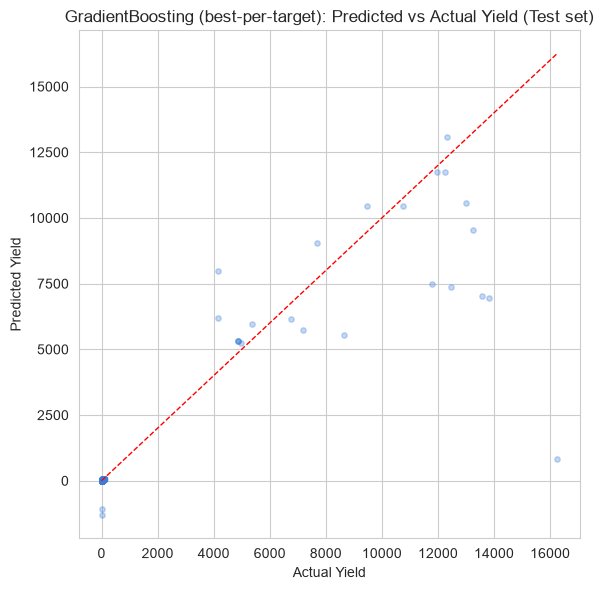

In [25]:
# Predicted vs actual for Yield on the held-out test set — sanity check for the main output
preds_test = final_model.predict(X_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test['Yield'], preds_test[:, 0], alpha=0.3, s=15, color='#3b7dd8')
lims = [0, max(y_test['Yield'].max(), preds_test[:, 0].max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Actual Yield')
ax.set_ylabel('Predicted Yield')
ax.set_title(f'{final_name}: Predicted vs Actual Yield (Test set)')
plt.tight_layout()
plt.show()


Saving the final model

In [26]:
import joblib

joblib.dump(final_model, 'final_model.joblib')
print('Saved to final_model.joblib')

# quick round-trip check: load it back and confirm predictions match
reloaded = joblib.load('final_model.joblib')
original_preds = final_model.predict(X_test.head(3))
reloaded_preds = reloaded.predict(X_test.head(3))
print('Predictions match after reload:', np.allclose(original_preds, reloaded_preds))

Saved to final_model.joblib
Predictions match after reload: True
